In [1]:
import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk"
os.environ["PYSPARK_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
spark = SparkSession.builder \
    .appName("IDS2018-Cascade") \
    .master("spark://lattitude7420:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.memory.storageFraction", "0.3") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("UI:", spark.sparkContext.uiWebUrl)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/22 15:21:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.8
UI: http://lattitude7420:4040


### Load Test + Load Models

In [4]:
test = spark.read.parquet("hdfs://lattitude7420:9000/ids2018/test")
test.cache()
print(f"Test rows: {test.count():,}")

model_binary  = PipelineModel.load("hdfs://lattitude7420:9000/ids2018/models/binary")
model_multi   = PipelineModel.load("hdfs://lattitude7420:9000/ids2018/models/multiclass_weighted")
print("Both models loaded!")

26/05/22 15:21:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Test rows: 1,806,815


Both models loaded!


### Binary Prediction

In [5]:
pred_stage1 = model_binary.transform(test) \
    .withColumnRenamed("prediction", "binary_pred") \
    .withColumnRenamed("probability", "binary_prob") \
    .withColumnRenamed("rawPrediction", "binary_raw") \
    .drop("raw_features", "features")

pred_stage1.cache()

# split into benign and attack
benign_flows = pred_stage1.filter(F.col("binary_pred") == 0.0)
attack_flows = pred_stage1.filter(F.col("binary_pred") == 1.0)

print(f"Stage 1 — Predicted Benign : {benign_flows.count():,}")
print(f"Stage 1 — Predicted Attack : {attack_flows.count():,}")

Stage 1 — Predicted Benign : 1,386,693


[Stage 47:==================================================>     (10 + 1) / 11]

Stage 1 — Predicted Attack : 420,122


### Multiclass on Attach Flows

In [6]:
pred_stage2 = model_multi.transform(attack_flows) \
    .withColumnRenamed("prediction", "mc_pred") \
    .withColumnRenamed("probability", "mc_prob") \
    .withColumnRenamed("rawPrediction", "mc_raw")

pred_stage2.cache()
print(f"Stage 2 predictions done: {pred_stage2.count():,} rows")

26/05/22 15:23:51 WARN DAGScheduler: Broadcasting large task binary with size 1550.5 KiB
26/05/22 15:24:20 WARN DAGScheduler: Broadcasting large task binary with size 1556.4 KiB
[Stage 51:==============================================>          (9 + 2) / 11]

Stage 2 predictions done: 420,122 rows


### MERGE RESULTS — ASSIGN FINAL LABEL

In [7]:
mc_labels = model_multi.stages[2].labels
print("Multiclass label mapping:", mc_labels)

from pyspark.sql.functions import array, lit, element_at

label_array = array(*[lit(l) for l in mc_labels])

# benign flows: final_label = "Benign"
benign_final = benign_flows.withColumn("final_label", lit("Benign"))

# attack flows: final_label = mc_labels[mc_pred index]
attack_final = pred_stage2.withColumn(
    "final_label",
    element_at(label_array, (F.col("mc_pred") + 1).cast("int"))
)

# union both — keep only columns needed for evaluation
keep_cols = ["attack_type", "binary_label", "final_label"]
cascade_results = benign_final.select(keep_cols) \
    .union(attack_final.select(keep_cols))

cascade_results.cache()
print(f"Total cascade results: {cascade_results.count():,}")

Multiclass label mapping: ['Benign', 'DDoS', 'DoS', 'Bot', 'FTP-BruteForce', 'SSH-Bruteforce', 'Infilteration', 'WebAttack']


26/05/22 15:24:21 WARN DAGScheduler: Broadcasting large task binary with size 1568.7 KiB
26/05/22 15:24:24 WARN DAGScheduler: Broadcasting large task binary with size 1574.2 KiB
[Stage 55:==================================================>     (20 + 2) / 22]

Total cascade results: 1,806,815


### Binary Level Evaluation

In [8]:
cascade_binary = cascade_results.withColumn(
    "cascade_binary_pred",
    F.when(F.col("final_label") == "Benign", 0.0).otherwise(1.0)
)

tp = cascade_binary.filter((F.col("cascade_binary_pred") == 1.0) & (F.col("binary_label") == 1.0)).count()
fp = cascade_binary.filter((F.col("cascade_binary_pred") == 1.0) & (F.col("binary_label") == 0.0)).count()
fn = cascade_binary.filter((F.col("cascade_binary_pred") == 0.0) & (F.col("binary_label") == 1.0)).count()
tn = cascade_binary.filter((F.col("cascade_binary_pred") == 0.0) & (F.col("binary_label") == 0.0)).count()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
prec   = tp / (tp + fp) if (tp + fp) > 0 else 0
f1     = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0
acc    = (tp + tn) / (tp + fp + fn + tn)

print("="*45)
print("   CASCADE — BINARY LEVEL RESULTS")
print("="*45)
print(f"  TP        : {tp:,}")
print(f"  FP        : {fp:,}")
print(f"  FN        : {fn:,}  ← key metric")
print(f"  TN        : {tn:,}")
print(f"  Recall    : {recall:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  F1        : {f1:.4f}")
print(f"  Accuracy  : {acc:.4f}")
print("="*45)

26/05/22 15:24:26 WARN DAGScheduler: Broadcasting large task binary with size 1577.0 KiB
26/05/22 15:24:27 WARN DAGScheduler: Broadcasting large task binary with size 1577.0 KiB
26/05/22 15:24:29 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:24:31 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
[Stage 67:==================================================>     (20 + 2) / 22]

   CASCADE — BINARY LEVEL RESULTS
  TP        : 415,518
  FP        : 4,104
  FN        : 30,090  ← key metric
  TN        : 1,357,103
  Recall    : 0.9325
  Precision : 0.9902
  F1        : 0.9605
  Accuracy  : 0.9811


### Per-class Evaluation

In [10]:
all_classes = ["Benign", "DDoS", "DoS", "Bot",
               "FTP-BruteForce", "SSH-Bruteforce", "Infilteration", "WebAttack"]

rows = []
for cls in all_classes:
    tp_c = cascade_results.filter(
        (F.col("final_label") == cls) & (F.col("attack_type") == cls)).count()
    fp_c = cascade_results.filter(
        (F.col("final_label") == cls) & (F.col("attack_type") != cls)).count()
    fn_c = cascade_results.filter(
        (F.col("final_label") != cls) & (F.col("attack_type") == cls)).count()

    prec_c = tp_c / (tp_c + fp_c) if (tp_c + fp_c) > 0 else 0
    rec_c  = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0
    f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c) if (prec_c + rec_c) > 0 else 0

    rows.append({
        'Class':     cls,
        'Precision': round(prec_c, 4),
        'Recall':    round(rec_c,  4),
        'F1':        round(f1_c,   4)
    })

per_class_df = pd.DataFrame(rows)
print(per_class_df.to_string(index=False))

26/05/22 15:25:04 WARN DAGScheduler: Broadcasting large task binary with size 1576.6 KiB
26/05/22 15:25:08 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:09 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:10 WARN DAGScheduler: Broadcasting large task binary with size 1576.6 KiB
26/05/22 15:25:11 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:13 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:14 WARN DAGScheduler: Broadcasting large task binary with size 1576.6 KiB
26/05/22 15:25:15 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:16 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:17 WARN DAGScheduler: Broadcasting large task binary with size 1576.6 KiB
26/05/22 15:25:18 WARN DAGScheduler: Broadcasting large task binary with size 1576.7 KiB
26/05/22 15:25:19 WAR

         Class  Precision  Recall     F1
        Benign     0.9783  0.9970 0.9876
          DDoS     0.9936  0.9967 0.9951
           DoS     0.9968  0.9979 0.9973
           Bot     0.9869  0.9977 0.9923
FTP-BruteForce     0.9941  1.0000 0.9970
SSH-Bruteforce     0.9999  0.9998 0.9998
 Infilteration     0.7884  0.0857 0.1546
     WebAttack     0.0038  0.0279 0.0066


### Confusion Matrix

26/05/22 15:25:31 WARN DAGScheduler: Broadcasting large task binary with size 1587.6 KiB
26/05/22 15:25:33 WARN DAGScheduler: Broadcasting large task binary with size 1588.7 KiB
                                                                                

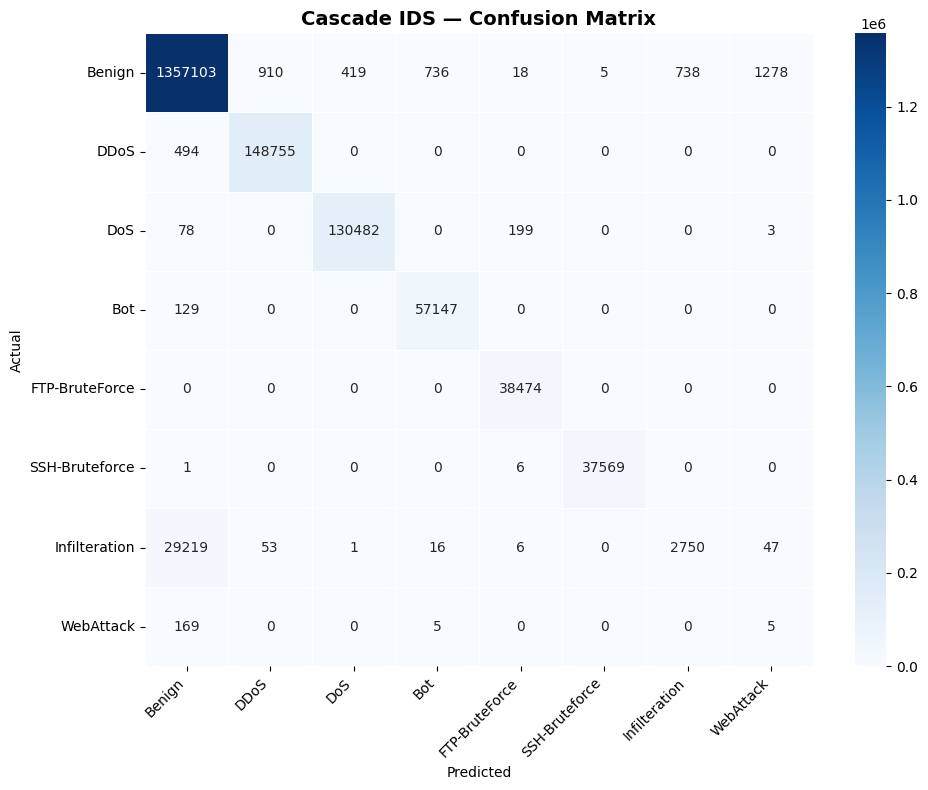

In [11]:
cm_raw = cascade_results.groupBy("attack_type", "final_label").count().toPandas()
n      = len(all_classes)
idx    = {c: i for i, c in enumerate(all_classes)}

cm_matrix = np.zeros((n, n))
for _, row in cm_raw.iterrows():
    i = idx.get(row['attack_type'])
    j = idx.get(row['final_label'])
    if i is not None and j is not None:
        cm_matrix[i][j] = row['count']

plt.figure(figsize=(10, 8))
sns.heatmap(cm_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=all_classes, yticklabels=all_classes, linewidths=0.5)
plt.title('Cascade IDS — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

### Comparison Table

In [12]:
print("\n" + "="*60)
print("   FULL MODEL COMPARISON")
print("="*60)

comparison = {
    'Binary RF':             {'FN': 30060, 'Benign Recall': 0.9988, 'Infil Recall': 0.0075, 'WebAttack Recall': 0.0000},
    'Multiclass RF':         {'FN': 33157, 'Benign Recall': 0.9988, 'Infil Recall': 0.0075, 'WebAttack Recall': 0.0000},
    'Weighted MC':           {'FN':  3923, 'Benign Recall': 0.6554, 'Infil Recall': 0.8636, 'WebAttack Recall': 0.9665},
    'Capped Weighted MC':    {'FN':  1900, 'Benign Recall': 0.6753, 'Infil Recall': 0.9459, 'WebAttack Recall': 0.4134},
    'Cascade (this run)':    {'FN': None,  'Benign Recall': None,   'Infil Recall': None,   'WebAttack Recall': None},
}

# fill cascade from per_class_df
for row in per_class_df.itertuples():
    if row.Class == 'Benign':
        comparison['Cascade (this run)']['Benign Recall'] = row.Recall
    if row.Class == 'Infilteration':
        comparison['Cascade (this run)']['Infil Recall'] = row.Recall
    if row.Class == 'WebAttack':
        comparison['Cascade (this run)']['WebAttack Recall'] = row.Recall

# FN from block 8
comparison['Cascade (this run)']['FN'] = fn

print(f"{'Model':<22} {'FN':>8} {'Benign R':>10} {'Infil R':>10} {'Web R':>10}")
print("-" * 64)
for model, m in comparison.items():
    print(f"{model:<22} {str(m['FN']):>8} {str(m['Benign Recall']):>10} "
          f"{str(m['Infil Recall']):>10} {str(m['WebAttack Recall']):>10}")


   FULL MODEL COMPARISON
Model                        FN   Benign R    Infil R      Web R
----------------------------------------------------------------
Binary RF                 30060     0.9988     0.0075        0.0
Multiclass RF             33157     0.9988     0.0075        0.0
Weighted MC                3923     0.6554     0.8636     0.9665
Capped Weighted MC         1900     0.6753     0.9459     0.4134
Cascade (this run)        30090      0.997     0.0857     0.0279
